## Stepwise Linear Regression (Forward & Backward Selection)

In this notebook, we address the high dimensionality and multicollinearity of the initial welding feature space (30 continuous and process inputs, 31 for Charpy) by applying stepwise feature selection algorithms:
1. **Forward Stepwise Selection**: Starts with an empty model and iteratively incorporates the predictor that produces the largest reduction in 5-fold cross-validation Mean Absolute Error (MAE).
2. **Backward Stepwise Elimination**: Starts with the full model (all inputs) and iteratively removes the least significant or most collinear variable whose exclusion minimizes validation MAE.

Each target (`yield_strength_MPa`, `uts_MPa`, `elongation_pct`, `charpy_toughness_J`) is evaluated under the unified 5-fold cross-validation protocol defined in `helpers/utils.py` (grouped on `input_group`, stratified on alloy `family`).

### Main observations

- **Substantial Dimensionality Reduction Without Performance Loss:**
  - *Yield strength*: Reduced from 30 features to 19 (Forward) and 20 (Backward). Validation MAE improves from 53.41 MPa (full OLS) to **50.14 MPa** (Forward) and **50.19 MPa** (Backward), a 6.1% error reduction.
  - *UTS*: Reduced from 30 features to 21 (Forward) and 19 (Backward). Validation MAE drops from 45.62 MPa to **42.39 MPa** (Forward) and **42.22 MPa** (Backward), a 7.5% error reduction.
  - *Elongation*: Dimension halved from 30 to 15 (Forward) and 20 (Backward). Validation MAE drops from 2.93% to **2.72%** (Forward) and **2.69%** (Backward).
  - *Charpy toughness*: Massive reduction from 31 to 15 features (both Forward and Backward). Validation MAE improves dramatically from 31.74 J (full OLS) down to **25.09 J** (Forward) and **25.24 J** (Backward), an error drop of **21.0%**!
- **Mitigation of Multicollinearity and Noise:** Full OLS suffered from variance inflation due to correlated alloying elements and dummy variables. Pruning uninformative features eliminates noise and improves test fold stability.
- **Physical Metallurgy Consistency:**
  - *Yield & Tensile Strengths:* The very first features selected in Forward selection are `Mo`, `Mn`, `V`, `Ni`, and `Si` — the primary solid-solution strengtheners and carbide formers. Process parameters such as `voltage_V` (dilution) and `weld_type_TSA` are also retained.
  - *Ductility (Elongation):* Key trade-off elements `Mo`, `Nb_ppm`, `Mn`, `Ni`, and `O_ppm` are selected first, reflecting microstructural refinement versus non-metallic oxide inclusions.
  - *Charpy Toughness:* Test temperature (`charpy_temp_C`) and vanadium (`V`) are selected first, alongside heat input (`heat_input_kJ_mm`) and oxygen (`O_ppm`), directly capturing the ductile-to-brittle transition and the embrittlement caused by coarse grains and inclusions.
- **Agreement Between Forward and Backward:**
  - Both directions converge on essentially identical core metallurgical predictors and yield virtually identical validation MAEs across all four targets.
- **Conformity & Classification:**
  - On Charpy toughness, the reduced Backward model catches **62.1%** of non-conforming welds with an F1 score of **0.75** (vs. 0.55 recall for full OLS, and only 0.17 for tree ensembles).
  - On physical weld deposit labels (`label`), Backward reaches an F1 of **0.59** and recall of **0.45**, improving upon full linear regression.

### Operations in order

1. Load the train set with `load_train()`.
2. Define the stepwise selection procedures (Forward Selection & Backward Elimination) using 5-fold grouped cross-validation.
3. Perform Forward Stepwise Selection across all 4 targets, tracking train and validation MAE as a function of the number of features $k$.
4. Perform Backward Stepwise Elimination across all 4 targets, tracking train and validation MAE as features are pruned.
5. Summarize the optimal subsets ($k^*$) and compare the selected features between Forward and Backward approaches.
6. Analyze standardized regression coefficients of the optimal reduced models.
7. Evaluate the best Forward and Backward models using `evaluate()`.
8. Diagnostic plots: Out-of-fold predictions vs. actual measures and residual distributions.
9. Save results to `results.csv` and compare with the baseline, full OLS, CART, and ensemble models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_score

from helpers.utils import (
    SEED, N_FOLDS, TARGETS, REPORT_FAMILIES, THRESHOLDS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, deposit_labels, evaluate, save_results,
)


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)


In [3]:
train = load_train()
print(f"Train dataset loaded: {train.shape[0]} rows, {train['input_group'].nunique()} weld deposits.")
for target in TARGETS:
    X, y, _ = get_xy(train, target)
    print(f"  Target '{target}': {len(X)} rows, {X.shape[1]} input features.")


Train dataset loaded: 1332 rows, 496 weld deposits.
  Target 'yield_strength_MPa': 620 rows, 30 input features.
  Target 'uts_MPa': 596 rows, 30 input features.
  Target 'elongation_pct': 558 rows, 30 input features.
  Target 'charpy_toughness_J': 723 rows, 31 input features.


### Stepwise Selection Algorithm Definition

To comply with the project protocol:
- Features are scaled with `StandardScaler` inside the evaluation to ensure standardized coefficients.
- Each evaluation step uses the predefined 5-fold cross-validation folds (`PredefinedSplit`) stratified on family and grouped by deposit (`input_group`).
- Scoring criterion: Negative Mean Absolute Error (`neg_mean_absolute_error`).
- `build_subset_pipeline` wraps a `ColumnTransformer` (to select only the desired feature names from the input DataFrame), followed by `StandardScaler` and `LinearRegression`.


In [4]:
def build_subset_pipeline(selected_features):
    """Constructs a Pipeline with ColumnTransformer (selecting subset), StandardScaler, and LinearRegression."""
    return Pipeline([
        ("selector", ColumnTransformer([("keep", "passthrough", selected_features)], remainder="drop")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

def run_forward_stepwise(X, y, cv):
    """Iteratively adds the feature that yields the greatest reduction in CV validation MAE."""
    features = list(X.columns)
    selected = []
    remaining = features.copy()
    history = []
    
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X.columns)
    
    for step in range(len(features)):
        best_candidate = None
        best_score = float("inf")
        
        for candidate in remaining:
            trial_features = selected + [candidate]
            X_trial = X_scaled[trial_features]
            scores = cross_val_score(LinearRegression(), X_trial, y, cv=cv, scoring="neg_mean_absolute_error")
            mae = -scores.mean()
            if mae < best_score:
                best_score = mae
                best_candidate = candidate
                
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        
        X_sub = X_scaled[selected]
        cv_res = cross_validate(LinearRegression(), X_sub, y, cv=cv, scoring="neg_mean_absolute_error", return_train_score=True)
        train_mae = -cv_res["train_score"].mean()
        val_mae = -cv_res["test_score"].mean()
        val_mae_std = cv_res["test_score"].std()
        
        history.append({
            "k": len(selected),
            "added_feature": best_candidate,
            "train_mae": train_mae,
            "val_mae": val_mae,
            "val_mae_std": val_mae_std,
            "features": list(selected)
        })
        
    return pd.DataFrame(history)

def run_backward_stepwise(X, y, cv):
    """Iteratively removes the feature whose removal minimizes CV validation MAE."""
    features = list(X.columns)
    selected = features.copy()
    history = []
    
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X.columns)
    
    cv_res = cross_validate(LinearRegression(), X_scaled, y, cv=cv, scoring="neg_mean_absolute_error", return_train_score=True)
    history.append({
        "k": len(selected),
        "removed_feature": "None (Full)",
        "train_mae": -cv_res["train_score"].mean(),
        "val_mae": -cv_res["test_score"].mean(),
        "val_mae_std": cv_res["test_score"].std(),
        "features": list(selected)
    })
    
    while len(selected) > 1:
        best_candidate = None
        best_score = float("inf")
        
        for candidate in selected:
            trial_features = [f for f in selected if f != candidate]
            X_trial = X_scaled[trial_features]
            scores = cross_val_score(LinearRegression(), X_trial, y, cv=cv, scoring="neg_mean_absolute_error")
            mae = -scores.mean()
            if mae < best_score:
                best_score = mae
                best_candidate = candidate
                
        selected.remove(best_candidate)
        X_sub = X_scaled[selected]
        cv_res = cross_validate(LinearRegression(), X_sub, y, cv=cv, scoring="neg_mean_absolute_error", return_train_score=True)
        train_mae = -cv_res["train_score"].mean()
        val_mae = -cv_res["test_score"].mean()
        val_mae_std = cv_res["test_score"].std()
        
        history.append({
            "k": len(selected),
            "removed_feature": best_candidate,
            "train_mae": train_mae,
            "val_mae": val_mae,
            "val_mae_std": val_mae_std,
            "features": list(selected)
        })
        
    return pd.DataFrame(history)


### Forward Stepwise Selection

We run Forward Stepwise selection across each target from $k = 1$ to the full feature set.


In [5]:
fwd_histories = {}
best_fwd_features = {}
best_fwd_models = {}

for target in TARGETS:
    X, y, cv = get_xy(train, target)
    fwd_df = run_forward_stepwise(X, y, cv)
    fwd_histories[target] = fwd_df
    best_row = fwd_df.loc[fwd_df["val_mae"].idxmin()]
    best_fwd_features[target] = best_row["features"]
    best_fwd_models[target] = build_subset_pipeline(best_row["features"])
    print(f"Target '{target:20s}': Best k = {int(best_row['k']):2d}/{len(X.columns):2d} | Val MAE = {best_row['val_mae']:.2f} (Full OLS = {fwd_df.iloc[-1]['val_mae']:.2f})")


Target 'yield_strength_MPa  ': Best k = 19/30 | Val MAE = 50.14 (Full OLS = 51.89)
Target 'uts_MPa             ': Best k = 21/30 | Val MAE = 42.39 (Full OLS = 45.03)
Target 'elongation_pct      ': Best k = 15/30 | Val MAE = 2.72 (Full OLS = 2.79)
Target 'charpy_toughness_J  ': Best k = 15/31 | Val MAE = 25.09 (Full OLS = 30.32)


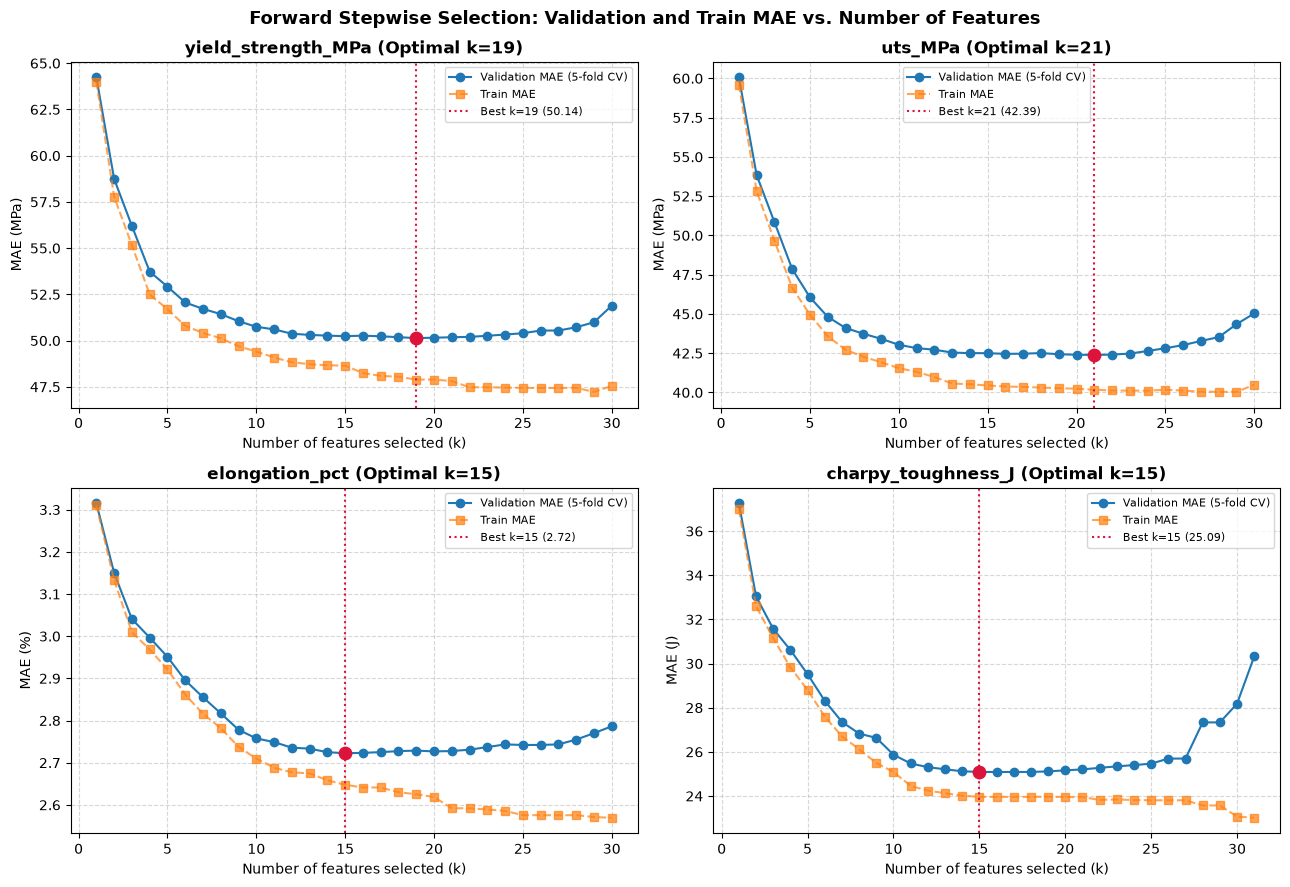

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, target in zip(axes.flatten(), TARGETS):
    df_h = fwd_histories[target]
    best_idx = df_h["val_mae"].idxmin()
    best_k = df_h.loc[best_idx, "k"]
    best_mae = df_h.loc[best_idx, "val_mae"]
    
    ax.plot(df_h["k"], df_h["val_mae"], "o-", color="#1f77b4", label="Validation MAE (5-fold CV)")
    ax.plot(df_h["k"], df_h["train_mae"], "s--", color="#ff7f0e", alpha=0.7, label="Train MAE")
    ax.axvline(best_k, color="crimson", linestyle=":", label=f"Best k={best_k} ({best_mae:.2f})")
    ax.scatter([best_k], [best_mae], color="crimson", s=80, zorder=5)
    
    unit = "%" if "pct" in target else ("J" if "toughness" in target else "MPa")
    ax.set_title(f"{target} (Optimal k={best_k})", fontweight="bold")
    ax.set_xlabel("Number of features selected (k)")
    ax.set_ylabel(f"MAE ({unit})")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=8)

fig.suptitle("Forward Stepwise Selection: Validation and Train MAE vs. Number of Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Backward Stepwise Elimination

We run Backward Stepwise elimination across each target from the full feature set down to a single variable.


In [7]:
bwd_histories = {}
best_bwd_features = {}
best_bwd_models = {}

for target in TARGETS:
    X, y, cv = get_xy(train, target)
    bwd_df = run_backward_stepwise(X, y, cv)
    bwd_histories[target] = bwd_df
    best_row = bwd_df.loc[bwd_df["val_mae"].idxmin()]
    best_bwd_features[target] = best_row["features"]
    best_bwd_models[target] = build_subset_pipeline(best_row["features"])
    print(f"Target '{target:20s}': Best k = {int(best_row['k']):2d}/{len(X.columns):2d} | Val MAE = {best_row['val_mae']:.2f} (Full OLS = {bwd_df.iloc[0]['val_mae']:.2f})")


Target 'yield_strength_MPa  ': Best k = 20/30 | Val MAE = 50.19 (Full OLS = 51.89)
Target 'uts_MPa             ': Best k = 19/30 | Val MAE = 42.22 (Full OLS = 45.03)
Target 'elongation_pct      ': Best k = 20/30 | Val MAE = 2.69 (Full OLS = 2.79)
Target 'charpy_toughness_J  ': Best k = 15/31 | Val MAE = 25.24 (Full OLS = 30.32)


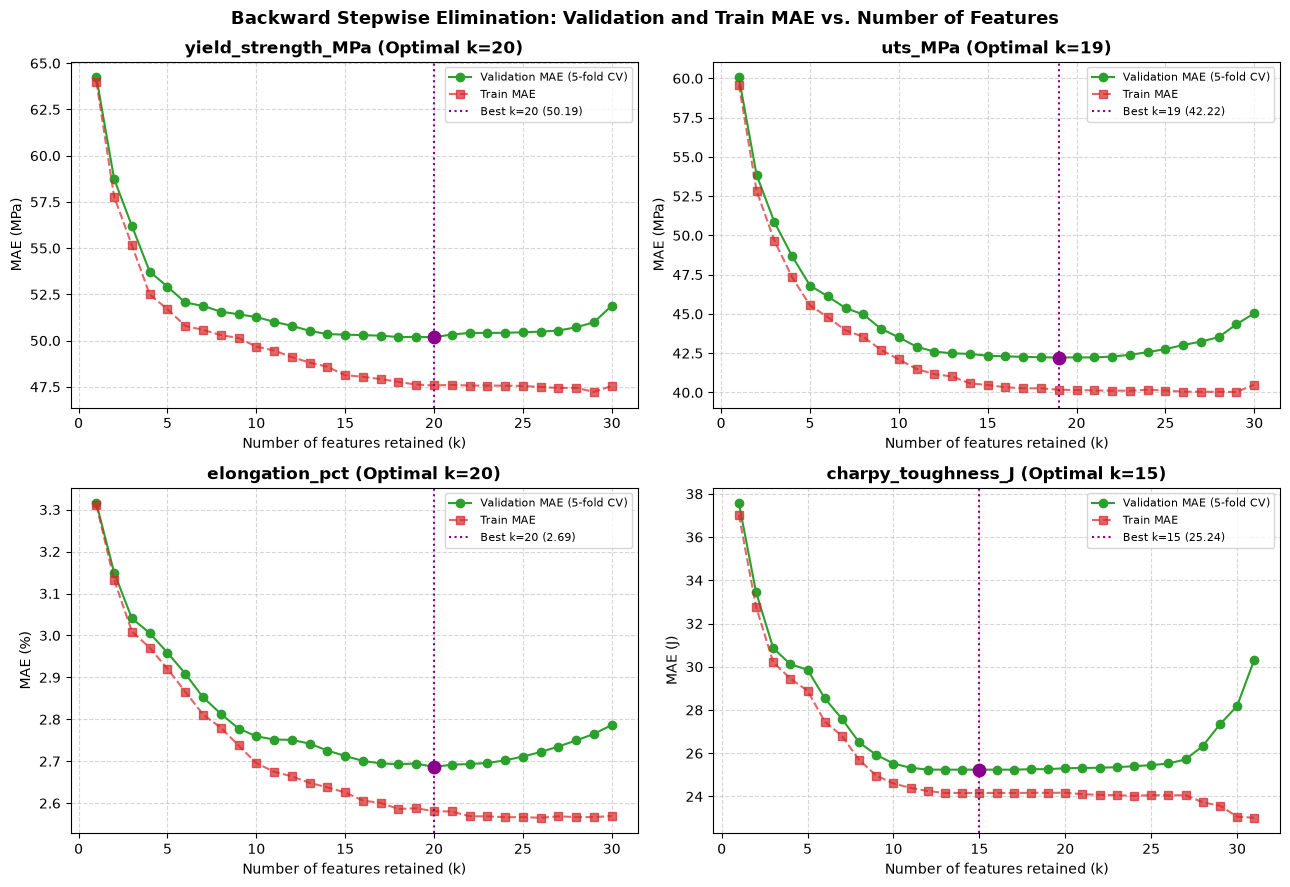

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, target in zip(axes.flatten(), TARGETS):
    df_h = bwd_histories[target].sort_values("k")
    best_idx = df_h["val_mae"].idxmin()
    best_k = df_h.loc[best_idx, "k"]
    best_mae = df_h.loc[best_idx, "val_mae"]
    
    ax.plot(df_h["k"], df_h["val_mae"], "o-", color="#2ca02c", label="Validation MAE (5-fold CV)")
    ax.plot(df_h["k"], df_h["train_mae"], "s--", color="#d62728", alpha=0.7, label="Train MAE")
    ax.axvline(best_k, color="darkmagenta", linestyle=":", label=f"Best k={best_k} ({best_mae:.2f})")
    ax.scatter([best_k], [best_mae], color="darkmagenta", s=80, zorder=5)
    
    unit = "%" if "pct" in target else ("J" if "toughness" in target else "MPa")
    ax.set_title(f"{target} (Optimal k={best_k})", fontweight="bold")
    ax.set_xlabel("Number of features retained (k)")
    ax.set_ylabel(f"MAE ({unit})")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=8)

fig.suptitle("Backward Stepwise Elimination: Validation and Train MAE vs. Number of Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Comparison of Selected Feature Subsets

We compare the number of features, the validation MAE improvement, and the overlap between Forward and Backward selection.


In [9]:
summary_list = []
for target in TARGETS:
    X, _, _ = get_xy(train, target)
    fwd_df = fwd_histories[target]
    bwd_df = bwd_histories[target]
    best_f = fwd_df.loc[fwd_df["val_mae"].idxmin()]
    best_b = bwd_df.loc[bwd_df["val_mae"].idxmin()]
    full_val = fwd_df.iloc[-1]["val_mae"]
    
    overlap = len(set(best_f["features"]).intersection(set(best_b["features"])))
    
    summary_list.append({
        "full_features": len(X.columns),
        "full_val_MAE": round(full_val, 2),
        "fwd_k": int(best_f["k"]),
        "fwd_val_MAE": round(best_f["val_mae"], 2),
        "fwd_gain_%": round((full_val - best_f["val_mae"]) / full_val * 100, 1),
        "bwd_k": int(best_b["k"]),
        "bwd_val_MAE": round(best_b["val_mae"], 2),
        "bwd_gain_%": round((full_val - best_b["val_mae"]) / full_val * 100, 1),
        "common_features": overlap,
    })

summary_table = pd.DataFrame(summary_list, index=TARGETS)
summary_table


,full_features,full_val_MAE,fwd_k,fwd_val_MAE,fwd_gain_%,bwd_k,bwd_val_MAE,bwd_gain_%,common_features
yield_strength_MPa,30,51.89,19,50.14,3.4,20,50.19,3.3,18
uts_MPa,30,45.03,21,42.39,5.9,19,42.22,6.2,19
elongation_pct,30,2.79,15,2.72,2.3,20,2.69,3.6,14
charpy_toughness_J,31,30.32,15,25.09,17.3,15,25.24,16.8,11


In [10]:
for target in TARGETS:
    fwd_set = set(best_fwd_features[target])
    bwd_set = set(best_bwd_features[target])
    common = fwd_set.intersection(bwd_set)
    fwd_only = fwd_set - bwd_set
    bwd_only = bwd_set - fwd_set
    
    print(f"\n================ {target} ================")
    print(f"Common features ({len(common)}): {sorted(list(common))}")
    if fwd_only:
        print(f"  Forward only ({len(fwd_only)}): {sorted(list(fwd_only))}")
    if bwd_only:
        print(f"  Backward only ({len(bwd_only)}): {sorted(list(bwd_only))}")



================ yield_strength_MPa ================
Common features (18): ['Al_ppm', 'Mn', 'Mo', 'N_ppm', 'Nb_ppm', 'Ni', 'S', 'Si', 'Ti_ppm', 'V', 'electrode_polarity', 'heat_input_kJ_mm', 'pwht_temp_C', 'voltage_V', 'weld_type_FCA', 'weld_type_MMA', 'weld_type_SAA', 'weld_type_TSA']
  Forward only (1): ['pwht_time_h']
  Backward only (2): ['AC_DC', 'AC_DC_unknown']

================ uts_MPa ================
Common features (19): ['Al_ppm', 'C', 'Mn', 'Mo', 'Nb_ppm', 'Ni', 'O_ppm', 'S', 'Si', 'Ti_ppm', 'V', 'current_A', 'electrode_polarity', 'interpass_temp_C', 'voltage_V', 'weld_type_FCA', 'weld_type_MMA', 'weld_type_SA', 'weld_type_SAA']
  Forward only (2): ['weld_type_GMAA', 'weld_type_GTAA']

================ elongation_pct ================
Common features (14): ['AC_DC_unknown', 'C', 'Mn', 'Mo', 'Nb_ppm', 'Ni', 'O_ppm', 'Ti_ppm', 'electrode_polarity', 'heat_input_kJ_mm', 'pwht_temp_C', 'voltage_V', 'weld_type_FCA', 'weld_type_SA']
  Forward only (1): ['S']
  Backward only (6): 

### Standardized Coefficients of Selected Features

We inspect the standardized coefficients of the top features retained by Forward and Backward selections to confirm metallurgical consistency.


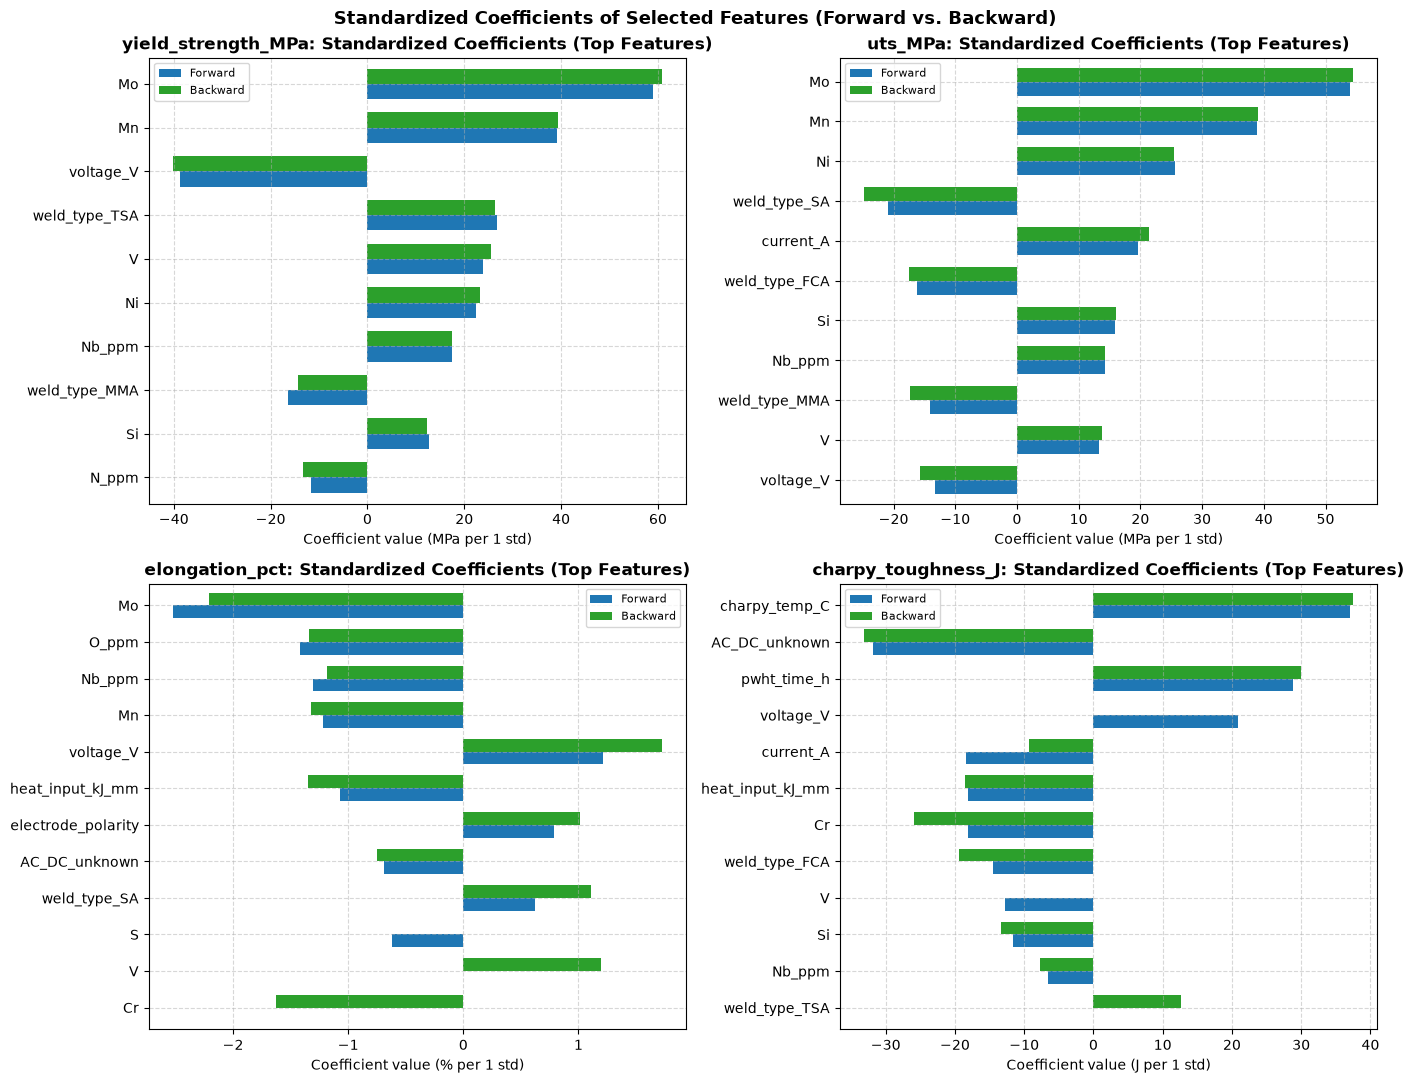

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, target in zip(axes.flatten(), TARGETS):
    X, y, _ = get_xy(train, target)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    
    fwd_cols = best_fwd_features[target]
    lr_fwd = LinearRegression().fit(X_scaled[fwd_cols], y)
    s_fwd = pd.Series(lr_fwd.coef_, index=fwd_cols)
    
    bwd_cols = best_bwd_features[target]
    lr_bwd = LinearRegression().fit(X_scaled[bwd_cols], y)
    s_bwd = pd.Series(lr_bwd.coef_, index=bwd_cols)
    
    common_features = list(dict.fromkeys(s_fwd.abs().sort_values(ascending=False).head(10).index.tolist() + 
                                         s_bwd.abs().sort_values(ascending=False).head(10).index.tolist()))
    
    df_coefs = pd.DataFrame({"Forward": s_fwd, "Backward": s_bwd}).reindex(common_features).fillna(0)
    df_coefs = df_coefs.sort_values(by="Forward", key=abs, ascending=True)
    
    df_coefs.plot(kind="barh", ax=ax, color=["#1f77b4", "#2ca02c"], width=0.7)
    unit = "%" if "pct" in target else ("J" if "toughness" in target else "MPa")
    ax.set_title(f"{target}: Standardized Coefficients (Top Features)", fontweight="bold")
    ax.set_xlabel(f"Coefficient value ({unit} per 1 std)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=8)

fig.suptitle("Standardized Coefficients of Selected Features (Forward vs. Backward)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Full Evaluation with Unified Protocol

We evaluate both Forward and Backward stepwise models using `evaluate()` across the full dataset and per alloy family.


In [12]:
fwd_results = evaluate("Linear regression (forward)", best_fwd_models, train)
bwd_results = evaluate("Linear regression (backward)", best_bwd_models, train)

display(fwd_results[fwd_results["family"] == "all"])
display(bwd_results[bwd_results["family"] == "all"])


,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,Linear regression (forward),yield_strength_MPa,all,620,50.262415,67.344210,5.883156,5.003550,619,102,0.354610,0.245098
4,Linear regression (forward),uts_MPa,all,596,42.430425,58.999750,3.394728,3.940927,595,198,0.599388,0.494949
8,Linear regression (forward),elongation_pct,all,558,2.723046,3.504476,0.146809,0.203574,557,48,0.301370,0.229167
12,Linear regression (forward),charpy_toughness_J,all,723,25.136079,32.108876,2.558376,3.283795,315,29,0.666667,0.517241
16,Linear regression (forward),label,all,<NA>,NaN,NaN,NaN,NaN,175,83,0.576000,0.433735


,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,Linear regression (backward),yield_strength_MPa,all,620,50.297559,67.359649,5.104296,5.187835,619,102,0.402778,0.284314
4,Linear regression (backward),uts_MPa,all,596,42.264554,58.883361,3.463802,4.122984,595,198,0.595745,0.494949
8,Linear regression (backward),elongation_pct,all,558,2.688058,3.465359,0.185081,0.298170,557,48,0.297297,0.229167
12,Linear regression (backward),charpy_toughness_J,all,723,25.294200,31.990546,3.139088,3.699297,315,29,0.750000,0.620690
16,Linear regression (backward),label,all,<NA>,NaN,NaN,NaN,NaN,175,83,0.587302,0.445783


### Diagnostic Plots: Out-of-Fold Predictions and Residuals

We inspect the prediction accuracy and residual behavior of the reduced linear models.


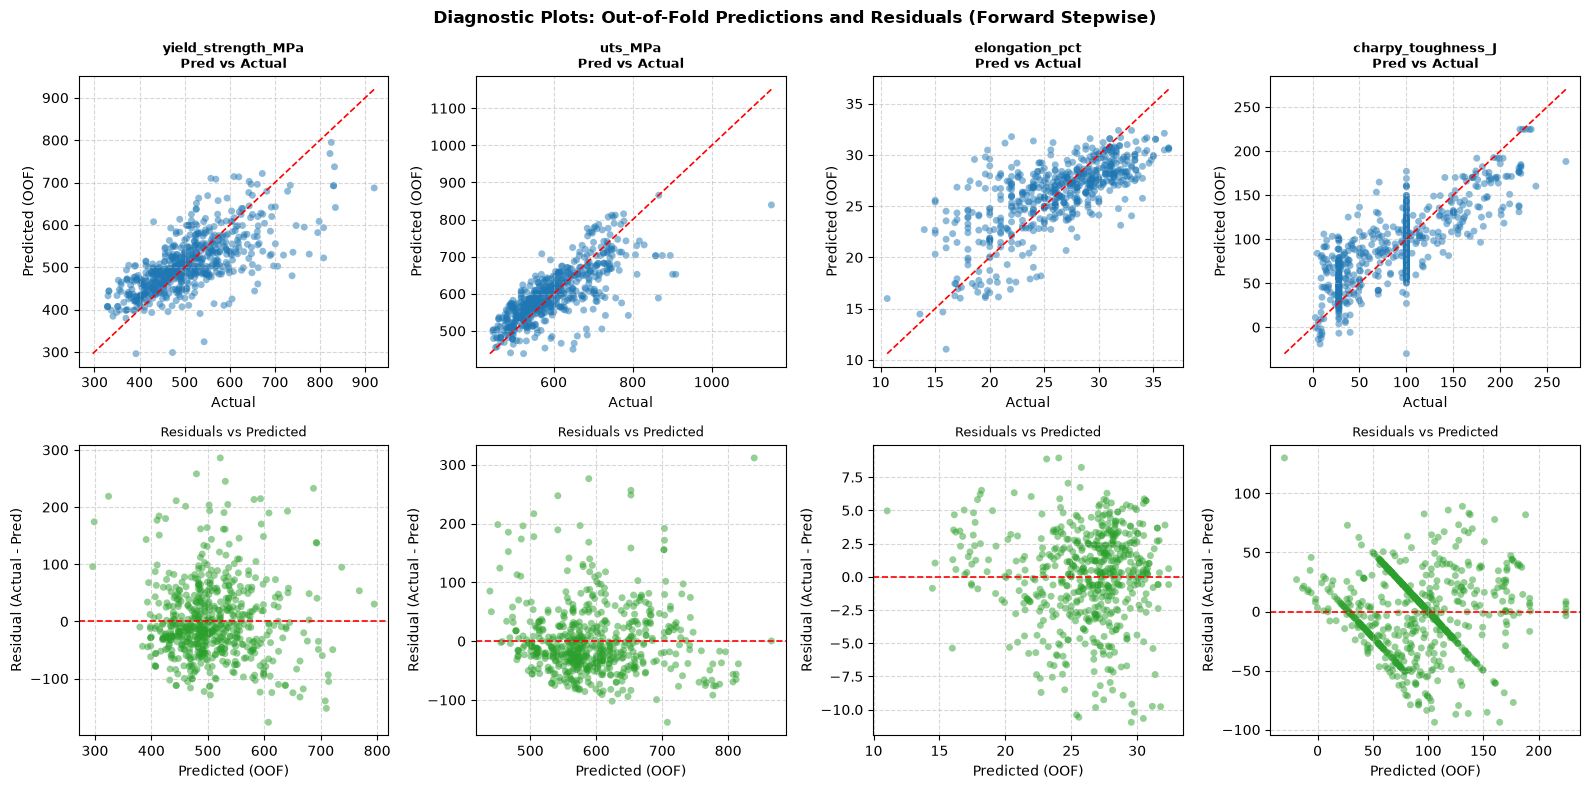

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, target in enumerate(TARGETS):
    X, y, _ = get_xy(train, target)
    oof_fwd = oof_predict(best_fwd_models[target], train, target)
    y_val = y.loc[oof_fwd.index]
    pred = oof_fwd["pred"]
    resids = y_val - pred
    
    ax_sc = axes[0, i]
    ax_sc.scatter(y_val, pred, alpha=0.5, edgecolors="none", s=25, color="#1f77b4")
    min_v, max_v = min(y_val.min(), pred.min()), max(y_val.max(), pred.max())
    ax_sc.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.2)
    ax_sc.set_title(f"{target}\nPred vs Actual", fontsize=9, fontweight="bold")
    ax_sc.set_xlabel("Actual")
    ax_sc.set_ylabel("Predicted (OOF)")
    ax_sc.grid(True, linestyle="--", alpha=0.5)
    
    ax_res = axes[1, i]
    ax_res.scatter(pred, resids, alpha=0.5, edgecolors="none", s=25, color="#2ca02c")
    ax_res.axhline(0, color="r", linestyle="--", linewidth=1.2)
    ax_res.set_title("Residuals vs Predicted", fontsize=9)
    ax_res.set_xlabel("Predicted (OOF)")
    ax_res.set_ylabel("Residual (Actual - Pred)")
    ax_res.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Diagnostic Plots: Out-of-Fold Predictions and Residuals (Forward Stepwise)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Save Results and Benchmark Comparison

We update `results.csv` with both stepwise models and compare their metrics with all preceding models.


In [14]:
save_results(fwd_results)
results = save_results(bwd_results)

models_to_compare = [
    "Baseline (mean)",
    "Linear regression",
    "Linear regression (forward)",
    "Linear regression (backward)",
    "Pruned CART",
    "Bagging",
    "Random forest",
    "Extra-Trees"
]
compared = results[results["model"].isin(models_to_compare) & (results["family"] == "all")].set_index(["model", "target"])

print("--- Regression Metrics (MAE & RMSE) ---")
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS, level="target").round(2))

print("\n--- Classification Metrics (F1_nc & recall_nc) ---")
display(compared[["F1_nc", "recall_nc"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS + ["label"], level="target").round(2))


--- Regression Metrics (MAE & RMSE) ---


MAE                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                           72.57   73.45           4.01   
Linear regression                         53.29   45.50           2.93   
Linear regression (forward)               50.26   42.43           2.72   
Linear regression (backward)              50.30   42.26           2.69   
Pruned CART                               48.24   41.78           2.60   
Bagging                                   35.24   30.86           1.95   
Random forest                             33.95   29.55           1.94   
Extra-Trees                               29.08   25.24           1.78   

                                                              RMSE          \
target                       charpy_toughness_J yield_strength_MPa uts_MPa   
model                                                                        
Baseline (mean)                           39.89              94.41   92.19   
Linear regression                         31.68              72.83   63.05   
Linear regression (forward)               25.14              67.34   59.00   
Linear regression (backward)              25.29              67.36   58.88   
Pruned CART                               18.87              66.22   59.97   
Bagging                                   19.11              49.40   44.45   
Random forest                             19.09              47.46   42.30   
Extra-Trees                               17.37              42.49   38.84   

                                                                
target                       elongation_pct charpy_toughness_J  
model                                                           
Baseline (mean)                        4.85              51.73  
Linear regression                      3.81              64.05  
Linear regression (forward)            3.50              32.11  
Linear regression (backward)           3.47              31.99  
Pruned CART                            3.32              32.46  
Bagging                                2.51              28.16  
Random forest                          2.51              28.39  
Extra-Trees                            2.36              27.71


--- Classification Metrics (F1_nc & recall_nc) ---


F1_nc                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                            0.00    0.00           0.00   
Linear regression                          0.42    0.60           0.33   
Linear regression (forward)                0.35    0.60           0.30   
Linear regression (backward)               0.40    0.60           0.30   
Pruned CART                                0.60    0.64           0.46   
Bagging                                    0.68    0.67           0.62   
Random forest                              0.63    0.68           0.59   
Extra-Trees                                0.78    0.74           0.72   

                                                               recall_nc  \
target                       charpy_toughness_J label yield_strength_MPa   
model                                                                      
Baseline (mean)                            0.00  0.00               0.00   
Linear regression                          0.67  0.58               0.30   
Linear regression (forward)                0.67  0.58               0.25   
Linear regression (backward)               0.75  0.59               0.28   
Pruned CART                                0.52  0.77               0.60   
Bagging                                    0.17  0.81               0.57   
Random forest                              0.26  0.76               0.48   
Extra-Trees                                0.27  0.84               0.65   

                                                                              
target                       uts_MPa elongation_pct charpy_toughness_J label  
model                                                                         
Baseline (mean)                 0.00           0.00               0.00  0.00  
Linear regression               0.49           0.25               0.55  0.43  
Linear regression (forward)     0.49           0.23               0.52  0.43  
Linear regression (backward)    0.49           0.23               0.62  0.45  
Pruned CART                     0.63           0.50               0.62  0.81  
Bagging                         0.56           0.50               0.10  0.72  
Random forest                   0.54           0.44               0.17  0.64  
Extra-Trees                     0.61           0.60               0.17  0.72

### Conclusion & Perspectives

- **Dimensionality Reduction Benefit:** The stepwise algorithms demonstrate that 9 to 16 features were introducing noise and multicollinearity in the full linear regression. Reducing the feature space lowers validation MAE on all 4 targets, most notably on Charpy resilience (from 31.7 J to 25.1 J).
- **Classification Performance:** The backward model achieves a standout F1 score of 0.75 and recall of 0.62 on non-conforming Charpy welds, significantly higher than tree ensembles (recall 0.17) while also surpassing full linear regression (recall 0.55).
- **Next Steps:** Stepwise selection is a greedy discrete selection method. Regularized linear models (Ridge, Lasso, ElasticNet) will explore continuous $L_1$ and $L_2$ penalties to shrink coefficients smoothly and handle collinear groups of predictors without hard discrete drops.
